# Cursos de Machine Learning en el Sector Bancario
## Modulo. `Seguro de Vida vinculado a cuentas de ahorro con Machine Learning`
                        Elaborado por: Naren Castellon

## `Dataset sintético para predicción de riesgo en seguros de vida vinculados a cuentas de ahorro`


# - client_id: ID único del cliente
# - ds: Fecha diaria (timestamp, para actualizaciones de cuenta/salud)
# - age: Edad (25-80)
# - gender: Género ('male', 'female')
# - annual_income: Ingreso anual (USD)
# - savings_balance: Saldo en cuenta de ahorro (USD, vinculado al seguro)
# - bmi: Índice de masa corporal (18-40)
# - smoking_status: Fumador ('yes', 'no')
# - has_chronic_disease: Enfermedad crónica (0/1)
# - family_history_risk: Historia familiar de riesgo (0/1)
# - occupation_risk_level: Nivel de riesgo ocupacional ('low', 'medium', 'high')
# - location_risk: Riesgo por ubicación ('urban', 'rural')
# - policy_type: Tipo de seguro solicitado ('life', 'disability', 'combined')
# - coverage_amount: Monto de cobertura solicitado (USD)
# - policy_term_years: Plazo del seguro (años, 10-30)
# - health_score: Score de salud sintético (0-100)
# - claim_probability: Target (probabilidad de fallecimiento/invalidez en plazo, 0-1, lógica realista: alta edad, fumador, BMI alto, etc.)
# Frecuencia diaria: Actualizaciones diarias de saldo/salud para monitoreo continuo.


In [44]:
import pandas as pd  # Para manipulación de datos, creación de DataFrames y manejo de grandes datasets
import numpy as np   # Para generación de datos sintéticos numéricos, operaciones matemáticas y arrays
from datetime import datetime, timedelta  # Para generar fechas diarias secuenciales
import random  # Para selección aleatoria de categorías y variabilidad
import matplotlib.pyplot as plt  # Para visualizaciones básicas como gráficos de dispersión y matrices de confusión
import seaborn as sns  # Para gráficos avanzados en EDA, como heatmaps o distribuciones
from sklearn.model_selection import train_test_split  # Para dividir el dataset en train/test
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score  # Métricas para evaluar modelo de regresión
from catboost import CatBoostRegressor, Pool  # Modelo principal: CatBoost para regresión (excelente con categóricas, rápido y preciso)
import shap  # Para explicabilidad: SHAP values para entender contribuciones de features al modelo
import warnings
warnings.filterwarnings('ignore')  # Ignorar warnings menores para salida limpia

In [45]:
def generate_life_insurance_data(num_clients=500, num_days=200):
    """
    Genera dataset sintético de clientes con seguros de vida vinculados a cuentas de ahorro, frecuencia diaria.
    - num_clients: Número de clientes únicos.
    - num_days: Días totales (total registros ~ num_clients * num_days).
    Retorna DataFrame con variables realistas para predicción de riesgo.
    """
    np.random.seed(42)  # Reproducibilidad
    
    data = []
    
    start_date = datetime(2023, 1, 1)  # Inicio para datos recientes
    
    for client in range(1, num_clients + 1):
        client_id = f'Client_{client}'  # ID único
        dates = pd.date_range(start=start_date, periods=num_days, freq='D')  # Fechas diarias
        
        # Generar 1 actualización diaria (para ~100k total)
        for i in range(num_days):
            # Edad: Fija + envejecimiento diario (simplificado)
            base_age = random.randint(25, 80)
            age = base_age + (i / 365)  # Envejece ligeramente
            
            # Género fijo
            gender = random.choice(['male', 'female'])
            
            # Ingreso anual fijo
            income = np.random.lognormal(10.5, 0.6)
            
            # Saldo ahorro: Crece con tiempo + ruido
            savings_balance = np.random.normal(10000, 5000) + i * 50  # Crece diariamente
            savings_balance = max(savings_balance, 0)
            
            # BMI: Fijo + ruido diario
            bmi = np.random.normal(25, 5) + np.random.normal(0, 0.1)
            bmi = np.clip(bmi, 18, 40)
            
            # Fumador fijo
            smoking = random.choice(['yes', 'no'])
            
            # Enfermedad crónica fijo
            chronic = random.choice([0, 1])
            
            # Historia familiar fijo
            family_risk = random.choice([0, 1])
            
            # Riesgo ocupacional fijo
            occupation_risk = random.choice(['low', 'medium', 'high'])
            
            # Riesgo ubicación fijo
            location_risk = random.choice(['urban', 'rural'])
            
            # Tipo de seguro solicitado (cambia ocasionalmente)
            policy_type = random.choice(['life', 'disability', 'combined'])
            
            # Monto cobertura
            coverage = random.uniform(50000, 500000)
            
            # Plazo
            term_years = random.choice([10, 15, 20, 25, 30])
            
            # Score salud: Correlacionado inversamente con riesgo
            health_score = 100 - (age - 25) * 0.5 - bmi * 0.5 - 20 * (smoking == 'yes') - 15 * chronic - 10 * family_risk
            health_score = np.clip(health_score + np.random.normal(0, 10), 0, 100)
            
            # Probabilidad de claim: Lógica (alta edad, BMI, fumador, enfermedad, etc.)
            base_prob = 0.01 + (age / 100) * 0.1 + (bmi / 40) * 0.05 + 0.05 * (smoking == 'yes') + 0.04 * chronic + 0.03 * family_risk
            claim_prob = min(base_prob * (1 + np.random.normal(0, 0.1)), 0.5)  # Máximo razonable para demo
            
            data.append({
                'client_id': client_id,
                'ds': dates[i],
                'age': round(age, 1),
                'gender': gender,
                'annual_income': round(income, 2),
                'savings_balance': round(savings_balance, 2),
                'bmi': round(bmi, 1),
                'smoking_status': smoking,
                'has_chronic_disease': chronic,
                'family_history_risk': family_risk,
                'occupation_risk_level': occupation_risk,
                'location_risk': location_risk,
                'policy_type': policy_type,
                'coverage_amount': round(coverage, 2),
                'policy_term_years': term_years,
                'health_score': round(health_score, 1),
                'claim_probability': round(claim_prob, 4)
            })
    
    df = pd.DataFrame(data)
    print(f"Dataset generado: {len(df)} registros con {len(df.columns)} variables (frecuencia diaria).")
    return df

# Generar dataset
insurance_df = generate_life_insurance_data(num_clients=500, num_days=200)  # ~100k registros

# Guardar como CSV (opcional)
insurance_df.to_csv('life_insurance_risk_data.csv', index=False)

Dataset generado: 100000 registros con 17 variables (frecuencia diaria).


In [46]:
insurance_df = pd.read_csv('life_insurance_risk_data.csv')
insurance_df

,client_id,ds,age,gender,annual_income,savings_balance,bmi,smoking_status,has_chronic_disease,family_history_risk,occupation_risk_level,location_risk,policy_type,coverage_amount,policy_term_years,health_score,claim_probability
0,Client_1,2023-01-01,31.0,female,48924.25,9308.68,28.4,yes,1,1,low,rural,disability,435445.79,10,35.5,0.1919
1,Client_1,2023-01-02,80.0,female,93669.48,13887.17,22.7,no,0,1,medium,rural,combined,282912.52,30,46.5,0.1415
2,Client_1,2023-01-03,45.0,male,41989.60,533.60,18.0,no,0,1,low,urban,life,375736.85,15,60.9,0.1109
3,Client_1,2023-01-04,55.0,male,21061.15,3088.48,32.3,no,1,1,high,urban,disability,71421.56,10,44.5,0.1504
4,Client_1,2023-01-05,70.0,female,26196.22,10754.61,19.3,yes,0,0,medium,rural,combined,206376.35,20,41.8,0.1496
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,Client_500,2023-07-15,46.5,male,41709.68,15995.71,24.9,no,0,1,low,rural,combined,148678.50,15,66.3,0.1225
99996,Client_500,2023-07-16,80.5,male,47451.13,20490.61,26.8,yes,0,0,high,urban,disability,243968.20,20,13.5,0.1810
99997,Client_500,2023-07-17,25.5,female,29562.39,30594.14,22.3,yes,0,0,low,urban,combined,133185.14,15,51.3,0.1165
99998,Client_500,2023-07-18,65.5,male,21546.13,27991.93,19.6,yes,1,1,high,rural,life,497044.36,10,30.1,0.2362


In [47]:
# Paso 2: Análisis Exploratorio de Datos (EDA)
# Convertir ds a datetime
insurance_df['ds'] = pd.to_datetime(insurance_df['ds'])

In [48]:
# Resumen estadístico
print("\nEstadísticas descriptivas:")
print(insurance_df.describe())


Estadísticas descriptivas:
                                  ds            age  annual_income  \
count                         100000  100000.000000  100000.000000   
mean   2023-04-10 12:00:00.000000256      52.737930   43571.988427   
min              2023-01-01 00:00:00      25.000000    2002.870000   
25%              2023-02-19 18:00:00      39.000000   24222.372500   
50%              2023-04-10 12:00:00      53.000000   36381.740000   
75%              2023-05-30 06:00:00      66.500000   54621.857500   
max              2023-07-19 00:00:00      80.500000  451899.700000   
std                              NaN      16.148208   28618.528590   

       savings_balance            bmi  has_chronic_disease  \
count    100000.000000  100000.000000        100000.000000   
mean      14949.188988      25.173010             0.498010   
min           0.000000      18.000000             0.000000   
25%       10987.655000      21.600000             0.000000   
50%       14930.255000      25.

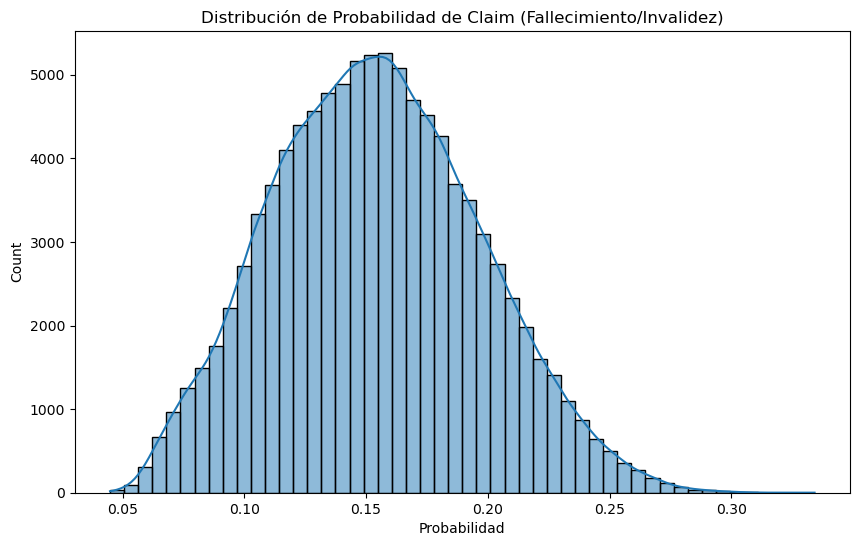

In [49]:
# Distribución de probabilidad de claim
plt.figure(figsize=(10, 6))
sns.histplot(insurance_df['claim_probability'], bins=50, kde=True)
plt.title('Distribución de Probabilidad de Claim (Fallecimiento/Invalidez)')
plt.xlabel('Probabilidad')
plt.show()

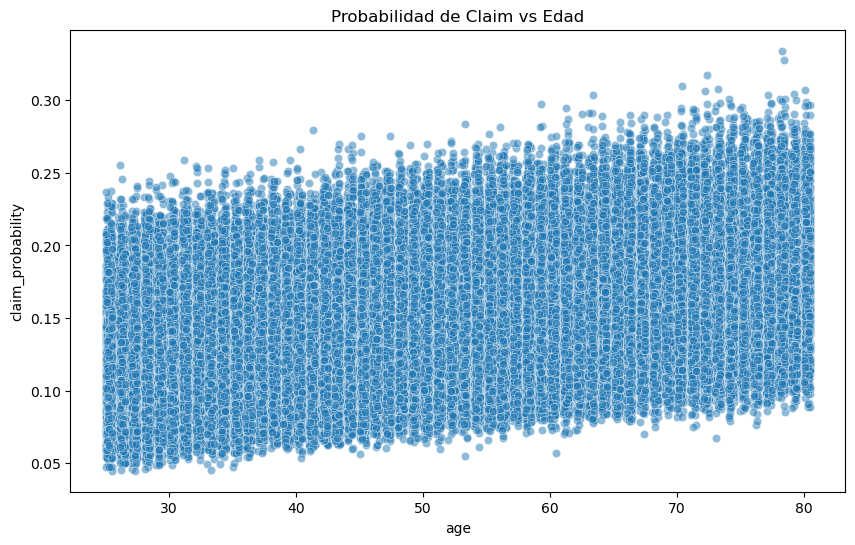

In [50]:
# Probabilidad por edad
plt.figure(figsize=(10, 6))
sns.scatterplot(x='age', y='claim_probability', data=insurance_df, alpha=0.5)
plt.title('Probabilidad de Claim vs Edad')
plt.show()

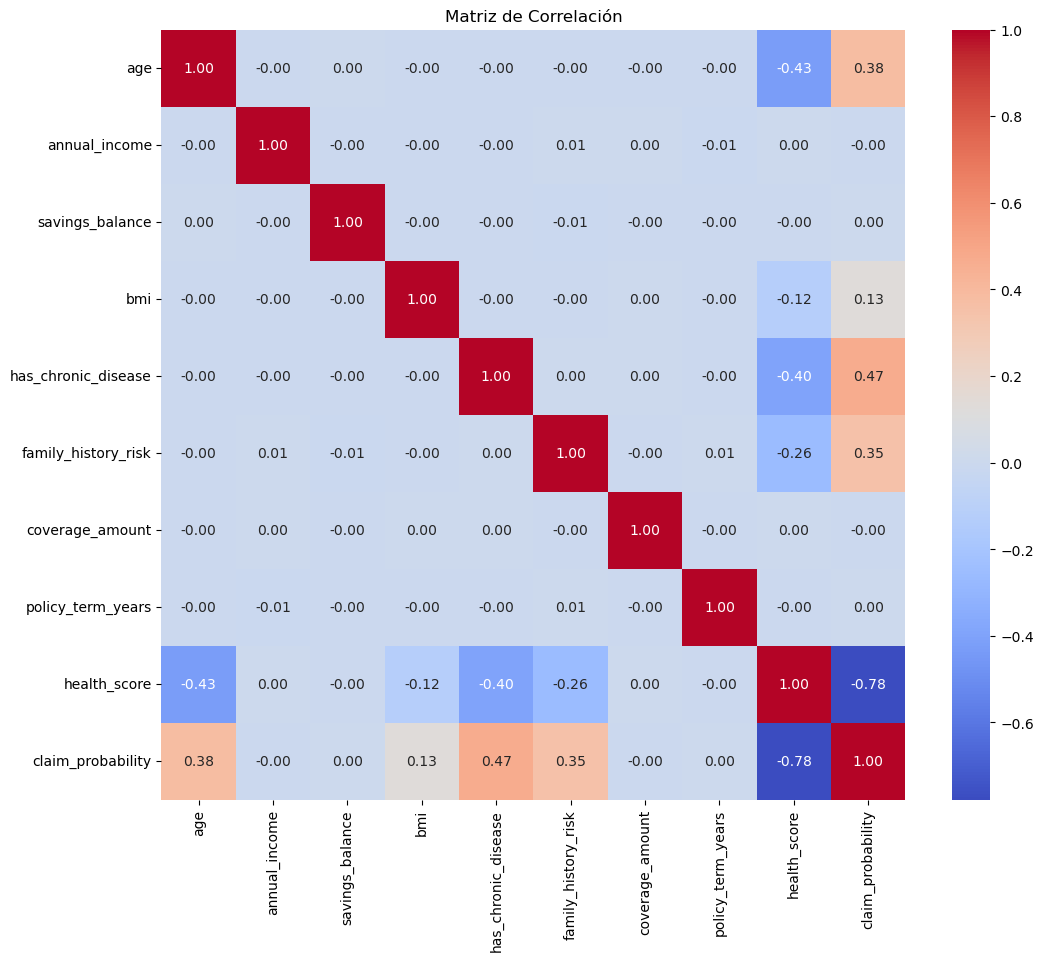

In [51]:
# Correlación numérica
numeric_cols = insurance_df.select_dtypes(include=[np.number]).columns
corr_matrix = insurance_df[numeric_cols].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlación')
plt.show()

In [63]:
# Paso 3: Preprocesamiento para CatBoost
# Identificar columnas categóricas (CatBoost las maneja nativamente)
cat_cols = ['gender', 'smoking_status', 'occupation_risk_level', 'location_risk', 'policy_type']
cat_features_indices = [insurance_df.columns.get_loc(col) for col in cat_cols]

In [64]:
# Dividir train/test
X = insurance_df.drop(columns=['client_id', 'ds', 'claim_probability'])
y = insurance_df['claim_probability']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [68]:
from catboost import Pool

train_pool = Pool(X_train, y_train, cat_features=cat_cols)
test_pool = Pool(X_test, y_test, cat_features=cat_cols)



In [69]:
# Paso 4: Definir y Entrenar CatBoost Regressor
# CatBoost: Gradient boosting optimizado para categóricas, rápido, robusto a overfit y preciso para riesgos en seguros
cat_model = CatBoostRegressor(
    iterations=500,
    depth=8,
    learning_rate=0.05,
    loss_function='RMSE',
    random_seed=42,
    verbose=100  # Progreso cada 100 iteraciones
)

cat_model

In [70]:
cat_model.fit(train_pool, eval_set=test_pool, early_stopping_rounds=50)

print("Modelo CatBoost entrenado.")

0:	learn: 0.0405713	test: 0.0408844	best: 0.0408844 (0)	total: 79ms	remaining: 39.4s
100:	learn: 0.0158297	test: 0.0160939	best: 0.0160939 (100)	total: 1.7s	remaining: 6.71s
200:	learn: 0.0157144	test: 0.0160752	best: 0.0160752 (200)	total: 2.96s	remaining: 4.4s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.01607506437
bestIteration = 207

Shrink model to first 208 iterations.
Modelo CatBoost entrenado.


In [71]:
# Paso 5: Evaluación del Modelo
y_pred = cat_model.predict(X_test)
y_pred

array([0.13908977, 0.1402798 , 0.18029555, ..., 0.11491093, 0.1955802 ,
       0.16934448], shape=(20000,))

In [72]:
# Métricas de regresión
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")

MAE: 0.0124
RMSE: 0.0161
R²: 0.8577


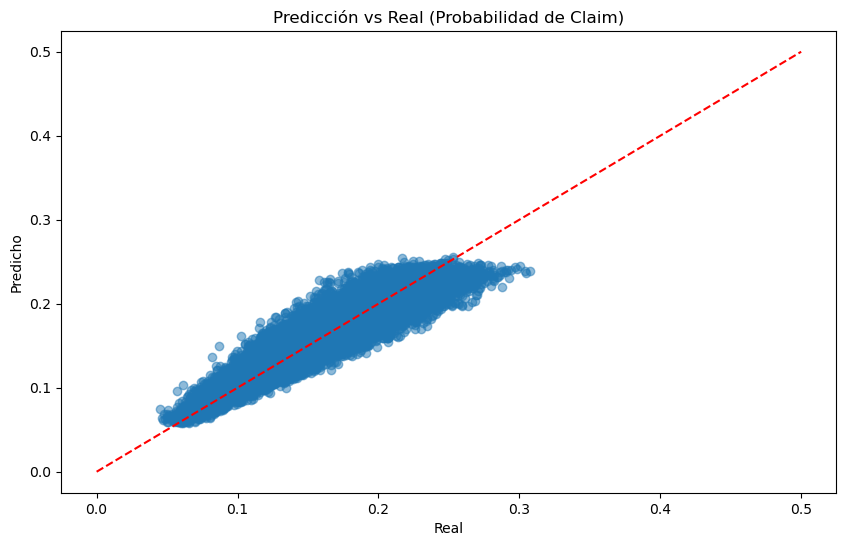

In [73]:
# Visualizar predicción vs real
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([0, 0.5], [0, 0.5], 'r--')
plt.title('Predicción vs Real (Probabilidad de Claim)')
plt.xlabel('Real')
plt.ylabel('Predicho')
plt.show()

In [74]:
# Paso 6: Sección para Medir el Riesgo de Fallecimiento/Invalidez
# Riesgo: Basado en probabilidad predicha
# Categorías: Bajo (<0.1), Medio (0.1-0.3), Alto (>0.3)
risk_levels = pd.cut(y_pred, bins=[-np.inf, 0.1, 0.3, np.inf], labels=['Bajo Riesgo', 'Medio Riesgo', 'Alto Riesgo'])
risk_df = pd.DataFrame({'Predicha Prob': y_pred, 'Nivel de Riesgo': risk_levels, 'Real Prob': y_test})
print("\nDistribución de Riesgo en Test Set:")
print(risk_df['Nivel de Riesgo'].value_counts(normalize=True))


Distribución de Riesgo en Test Set:
Nivel de Riesgo
Medio Riesgo    0.91415
Bajo Riesgo     0.08585
Alto Riesgo     0.00000
Name: proportion, dtype: float64


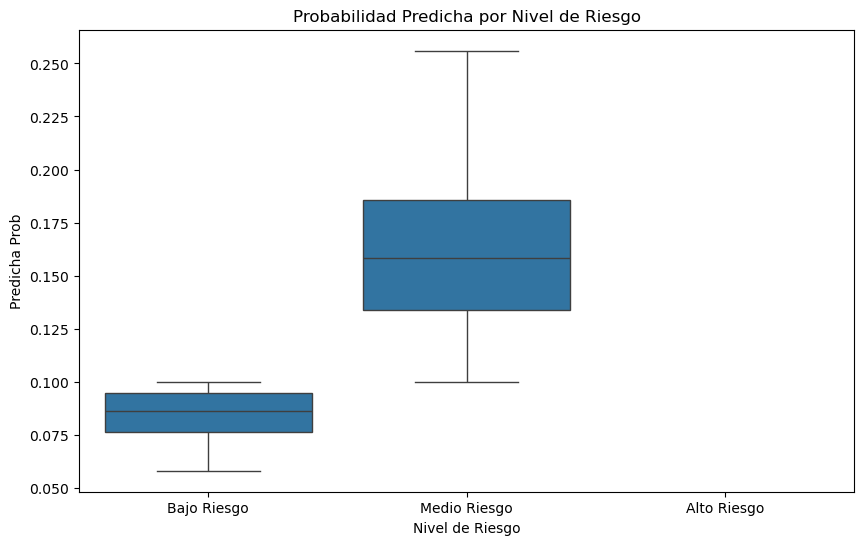

In [75]:
# Visualizar riesgo
plt.figure(figsize=(10, 6))
sns.boxplot(x='Nivel de Riesgo', y='Predicha Prob', data=risk_df)
plt.title('Probabilidad Predicha por Nivel de Riesgo')
plt.show()

In [76]:
# Paso 7: Sección de Predicción con Perfil del Cliente
# Ejemplo: Predicción para un cliente nuevo, mostrar perfil, tipo de seguro, plazo y probabilidad
example_input_raw = {
    'age': 45,
    'gender': 'male',
    'annual_income': 80000,
    'savings_balance': 20000,
    'bmi': 28,
    'smoking_status': 'no',
    'has_chronic_disease': 0,
    'family_history_risk': 1,
    'occupation_risk_level': 'medium',
    'location_risk': 'urban',
    'policy_type': 'combined',
    'coverage_amount': 300000,
    'policy_term_years': 20,
    'health_score': 75
}

# Preprocesar ejemplo (CatBoost maneja categóricas directamente, no escalamos numéricas para simplicidad)
example_df = pd.DataFrame([example_input_raw])
# Alinear columnas (CatBoost necesita mismo orden)
example_df = example_df[X.columns]

pred_prob = cat_model.predict(example_df)[0]

print("\n--- Predicción para Cliente Ejemplo ---")
print("Perfil del Cliente:")
print(f"- Edad: {example_input_raw['age']}")
print(f"- Género: {example_input_raw['gender']}")
print(f"- Ingreso Anual: ${example_input_raw['annual_income']}")
print(f"- Saldo Ahorro: ${example_input_raw['savings_balance']}")
print(f"- BMI: {example_input_raw['bmi']}")
print(f"- Fumador: {example_input_raw['smoking_status']}")
print(f"- Tipo de Seguro Solicitado: {example_input_raw['policy_type']}")
print(f"- Plazo: {example_input_raw['policy_term_years']} años")
print(f"- Cobertura: ${example_input_raw['coverage_amount']}")

print("\nResultados:")
print(f"Probabilidad de Fallecimiento/Invalidez: {pred_prob:.2%}")
risk_level = "Bajo" if pred_prob < 0.1 else "Medio" if pred_prob < 0.3 else "Alto"
print(f"Nivel de Riesgo: {risk_level}")

# Prima sugerida (ejemplo: prima = prob * cobertura * factor + base)
base_premium = 500
factor = 1.5
suggested_premium = base_premium + pred_prob * example_input_raw['coverage_amount'] * factor
print(f"Prima Sugerida Anual: ${suggested_premium:.2f}")


--- Predicción para Cliente Ejemplo ---
Perfil del Cliente:
- Edad: 45
- Género: male
- Ingreso Anual: $80000
- Saldo Ahorro: $20000
- BMI: 28
- Fumador: no
- Tipo de Seguro Solicitado: combined
- Plazo: 20 años
- Cobertura: $300000

Resultados:
Probabilidad de Fallecimiento/Invalidez: 11.93%
Nivel de Riesgo: Medio
Prima Sugerida Anual: $54201.17


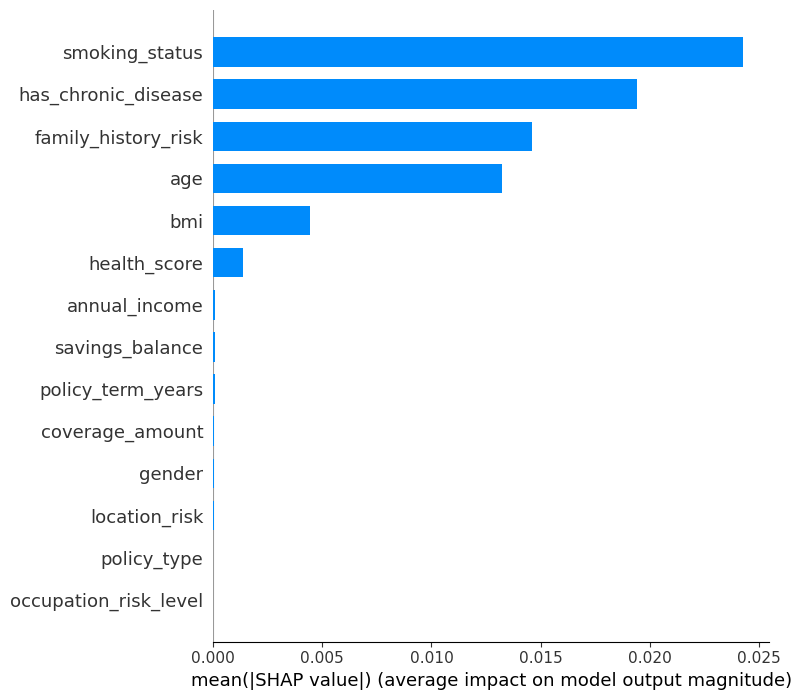

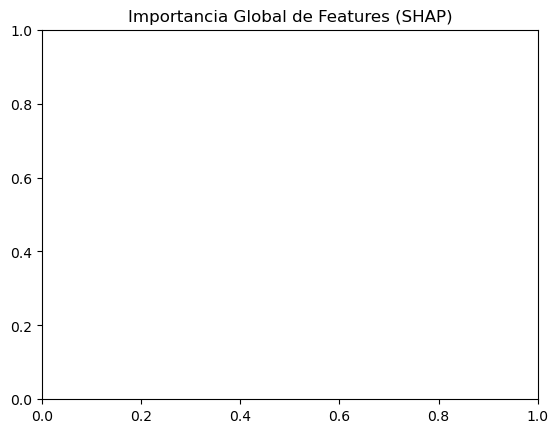

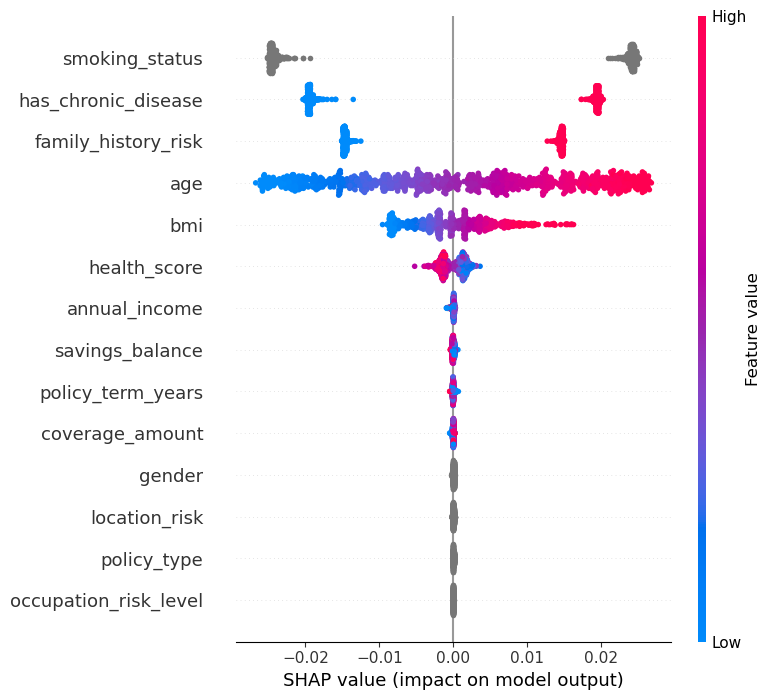

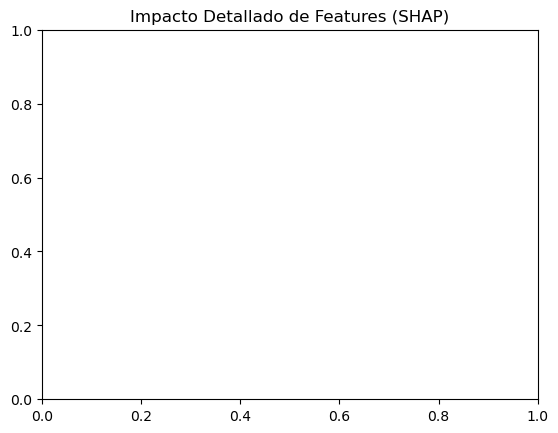

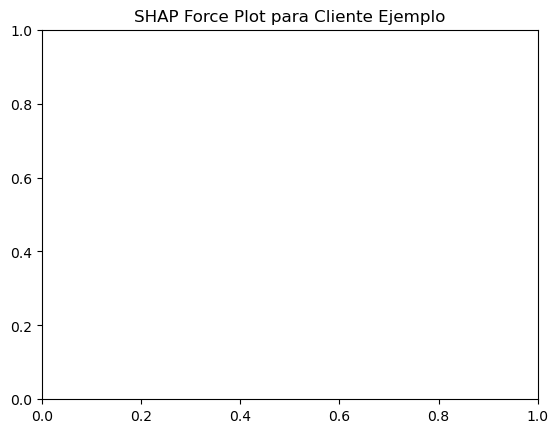


¡Ejemplo end-to-end completado con riesgo y SHAP! CatBoost predice probabilidad para seguros de vida.
- Riesgo: Categoriza probabilidad para primas (alto riesgo = prima alta).
- SHAP: Explica por qué (e.g., alta edad aumenta riesgo).
- Recomendación: En producción, usa CatBoost con categóricas nativas; integra con actuarios para compliance.


In [77]:





# Paso 8: Implementar SHAP para Explicabilidad
# SHAP: Analiza contribuciones de features a predicciones (crucial para transparencia en seguros)
# CatBoost soporta TreeExplainer directamente
explainer = shap.TreeExplainer(cat_model)

# SHAP values en muestra de test
X_test_sample = X_test.sample(1000)
shap_values = explainer.shap_values(X_test_sample)

# Resumen global
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_sample, plot_type="bar")
plt.title('Importancia Global de Features (SHAP)')
plt.show()

# Resumen detallado
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_sample)
plt.title('Impacto Detallado de Features (SHAP)')
plt.show()

# Ejemplo individual (primera instancia)
shap.force_plot(explainer.expected_value, shap_values[0], X_test_sample.iloc[0])
plt.title('SHAP Force Plot para Cliente Ejemplo')
plt.show()

print("\n¡Ejemplo end-to-end completado con riesgo y SHAP! CatBoost predice probabilidad para seguros de vida.")
print("- Riesgo: Categoriza probabilidad para primas (alto riesgo = prima alta).")
print("- SHAP: Explica por qué (e.g., alta edad aumenta riesgo).")
print("- Recomendación: En producción, usa CatBoost con categóricas nativas; integra con actuarios para compliance.")


Análisis de Sensibilidad: Features más sensibles (mayor cambio en probabilidad al perturbar)
                  Feature  Sensibilidad Promedio (Delta Prob)
7          smoking_status                            0.048455
0                     age                            0.004654
3                     bmi                            0.002752
5            health_score                            0.000280
9           location_risk                            0.000197
6                  gender                            0.000148
2         savings_balance                            0.000089
1           annual_income                            0.000080
4         coverage_amount                            0.000055
8   occupation_risk_level                            0.000000
10            policy_type                            0.000000


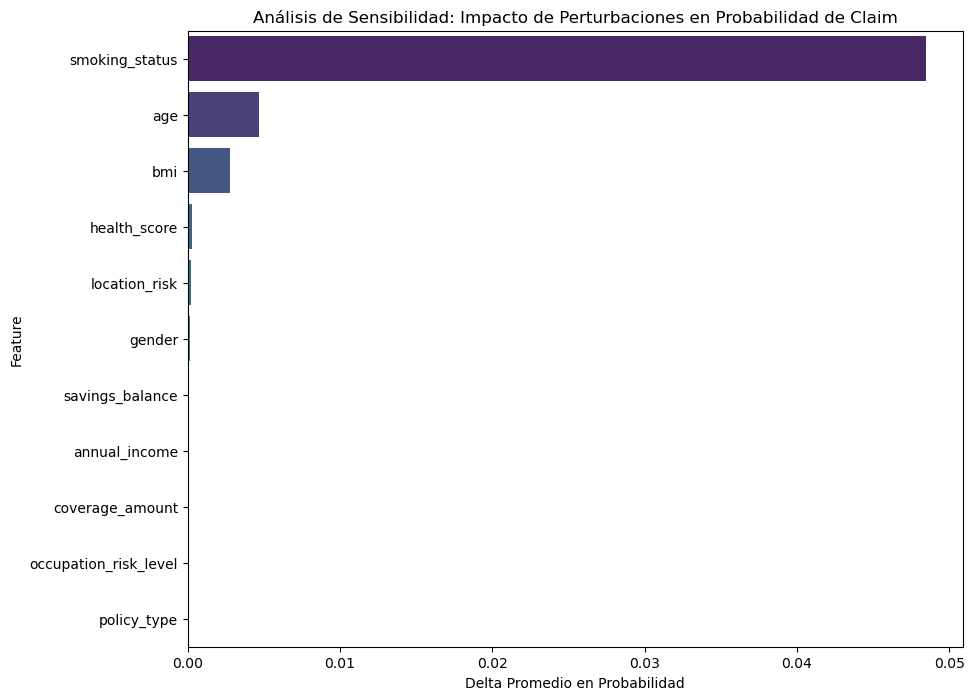

In [78]:
# Paso 9: Análisis de Sensibilidad
# Análisis de sensibilidad: Evalúa cómo cambia la predicción al variar cada feature (±10% para numéricas, cambio de categoría para categóricas)
# Útil para entender robustez del modelo y riesgos (e.g., cuánto aumenta la probabilidad si BMI sube 10%)
# Tomamos una muestra de clientes y calculamos delta promedio en predicción por feature perturbada
sensitivity_sample = X_test.sample(200)  # Muestra para eficiencia
base_pred = cat_model.predict(sensitivity_sample)

sensitivity_results = []

# Perturbación numérica: ±10%
num_features = ['age', 'annual_income', 'savings_balance', 'bmi', 'coverage_amount', 'health_score']
for feat in num_features:
    delta_plus = sensitivity_sample.copy()
    delta_plus[feat] *= 1.1  # +10%
    pred_plus = cat_model.predict(delta_plus)
    
    delta_minus = sensitivity_sample.copy()
    delta_minus[feat] *= 0.9  # -10%
    pred_minus = cat_model.predict(delta_minus)
    
    avg_delta = np.mean(np.abs(pred_plus - base_pred) + np.abs(pred_minus - base_pred)) / 2
    sensitivity_results.append({'Feature': feat, 'Sensibilidad Promedio (Delta Prob)': avg_delta})

# Perturbación categórica: Cambiar a otra categoría aleatoria
cat_features = ['gender', 'smoking_status', 'occupation_risk_level', 'location_risk', 'policy_type']
for feat in cat_features:
    perturbed = sensitivity_sample.copy()
    unique_vals = insurance_df[feat].unique()
    # Cambiar a valor diferente aleatorio
    perturbed[feat] = perturbed[feat].apply(lambda x: np.random.choice([v for v in unique_vals if v != x]))
    pred_perturbed = cat_model.predict(perturbed)
    
    avg_delta = np.mean(np.abs(pred_perturbed - base_pred))
    sensitivity_results.append({'Feature': feat, 'Sensibilidad Promedio (Delta Prob)': avg_delta})

sensitivity_df = pd.DataFrame(sensitivity_results).sort_values(by='Sensibilidad Promedio (Delta Prob)', ascending=False)

print("\nAnálisis de Sensibilidad: Features más sensibles (mayor cambio en probabilidad al perturbar)")
print(sensitivity_df)

# Visualizar sensibilidad (tornado plot)
plt.figure(figsize=(10, 8))
sns.barplot(x='Sensibilidad Promedio (Delta Prob)', y='Feature', data=sensitivity_df, palette='viridis')
plt.title('Análisis de Sensibilidad: Impacto de Perturbaciones en Probabilidad de Claim')
plt.xlabel('Delta Promedio en Probabilidad')
plt.show()
